# Lab05: Linear Regression Project

# ***************Multiple Linear Regression*************************

### Step 1: Import Packages
* **numpy, pandas, seabon**
* **from sklearn import preprocessing**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Step 2: Data preprocessing (Get Data + Manipulate Data) 
* **read csv "Ecommerce Customers.csv"**

In [4]:
# read csv
# Load the data
df = pd.read_csv('Ecommerce Customers.csv')


In [9]:
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [10]:
df.isnull().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


In [13]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [15]:
#Check columns name
df.columns


Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='str')

### Step 3: Exploratory Data Analysis (EDA)
* Let's create some simple plots to check out the data!

* using sns.heatmap(df.corr(), annot=True)

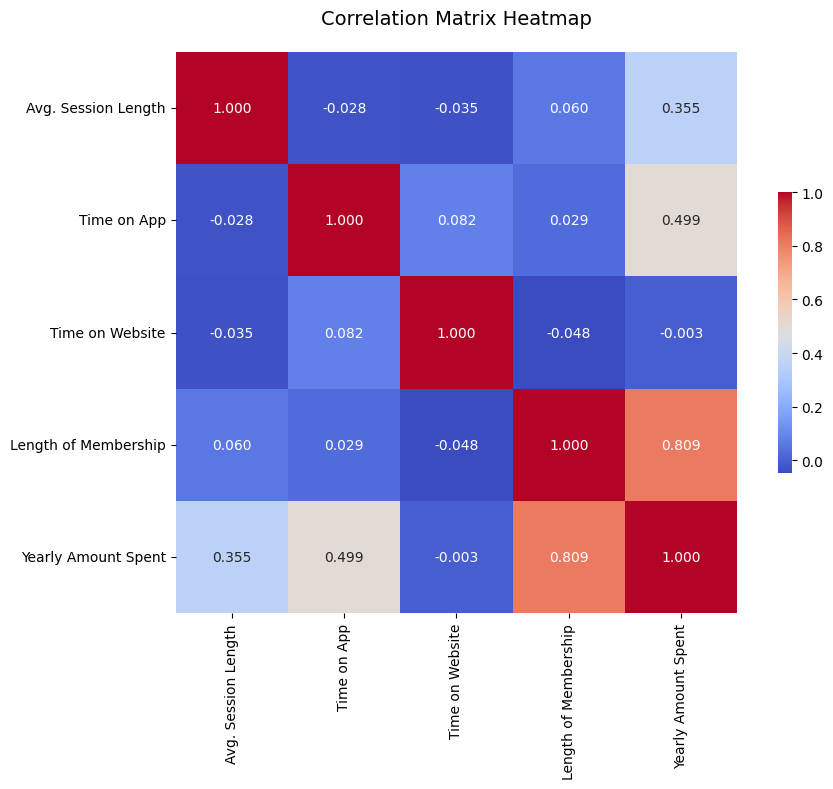

In [18]:
#check the correlation between features in the dataset
# Select numerical columns for correlation
numerical_cols = ['Avg. Session Length', 'Time on App', 'Time on Website', 
                  'Length of Membership', 'Yearly Amount Spent']

# Create correlation matrix
corr_matrix = df[numerical_cols].corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', 
            square=True, cbar_kws={"shrink": .5})
plt.title('Correlation Matrix Heatmap', fontsize=14, pad=20)
plt.tight_layout()
plt.show()




### Step 4: Training a Linear Regression Model

Let's now begin to train out regression model! We will need to first split up our data into an X array that contains the features to train on, and a y array with the target variable, in this case the Price column. We will toss out the Address column because it only has text info that the linear regression model can't use.

### X and y arrays

In [16]:
# check column features 
df.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='str')

In [ ]:
# X array of features for training
X = df[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]

X.head(3)


,Avg. Session Length,Time on App,Time on Website,Length of Membership
0,34.497268,12.655651,39.577668,4.082621
1,31.926272,11.109461,37.268959,2.664034
2,33.000915,11.330278,37.110597,4.104543


In [22]:
# y array with the target variable, in this case the "Yearly Amount Spent" column
y = df[['Yearly Amount Spent']]


y.head(3)

,Yearly Amount Spent
0,587.951054
1,392.204933
2,487.547505


### Step 5: Train Test Split
Now let's split the data into a training set and a testing set. We will train out model on the training set and then use the test set to evaluate the model.
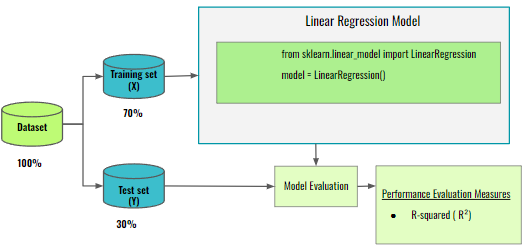

#### Import package of select model for split Training and Testing dataset
* **from sklearn.model_selection import train_test_split**

In [24]:
#Import package of select model for split Training and Testing dataset

from sklearn.model_selection import train_test_split

In [25]:
# Using function "train_test_split()" 
# Seperate dataset into 4 set: X_train, X_test, y_train and y_test
# test_size = 0.3 is mean seperate dataset into 70% for training and 30% for testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42  # for reproducibility
)


In [28]:
X_train.head(3)

,Avg. Session Length,Time on App,Time on Website,Length of Membership
5,33.871038,12.026925,34.476878,5.493507
116,33.925795,12.011022,36.701052,2.753424
45,34.555768,12.170525,39.131097,3.663105


In [15]:
X_test.head(3)

,Avg. Session Length,Time on App,Time on Website,Length of Membership
89,32.605584,12.068816,36.105001,3.917451
492,33.680937,11.201570,37.835448,2.208814
309,34.102279,8.508152,35.462400,1.838211


In [29]:
y_train.head(3)

,Yearly Amount Spent
5,637.102448
116,479.231093
45,549.860590


In [30]:
y_test.head(3)

,Yearly Amount Spent
361,401.033135
73,534.777188
374,418.602742


### Step 6: Creating and Training the Model
#### Using LinearRegression model for prediction
* **from sklearn.linear_model import LinearRegression**

In [31]:
#import package model Linear regression
from sklearn.linear_model import LinearRegression



In [32]:
# Create an instance of a linear regression model

model = LinearRegression()


In [33]:
#fit it to the data with the fit() function:
model.fit(X_train, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [34]:
#Get results
#Once you have your model fitted, you can get the results to verify that the model performs as expected and to interpret it.
#You can obtain the coefficient of determination, 𝑅², with .score() called on model:
# 𝑅²
print('Coefficient of determination: 𝑅² or Accuracy of Model Training :',model.score(X_train, y_train))
print('Coefficient of determination: 𝑅² or Accuracy of Model Testing :',model.score(X_test, y_test))


Coefficient of determination: 𝑅² or Accuracy of Model Training : 0.9854085988971646
Coefficient of determination: 𝑅² or Accuracy of Model Testing : 0.9808757641412775


### Step 7: Exploring our results 

In [35]:
#Predictin "Yearly Amount Spent" via using model
y_prediction = model.predict(X_test)

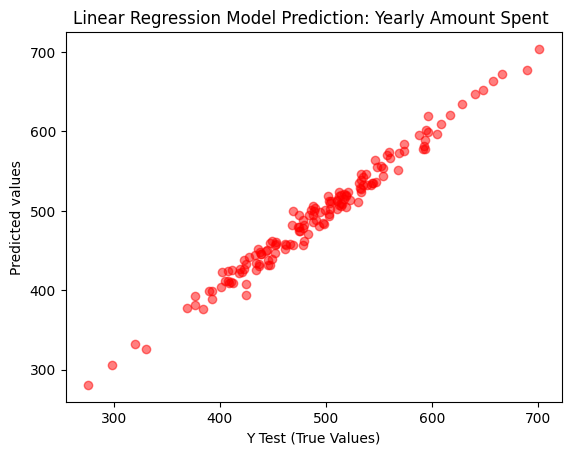

In [36]:
#Matplotlib: Scatter plot
plt.scatter(y_test,y_prediction, color='r', alpha=0.5)
plt.title("Linear Regression Model Prediction: Yearly Amount Spent ")
plt.xlabel('Y Test (True Values)')
plt.ylabel('Predicted values')
plt.show()

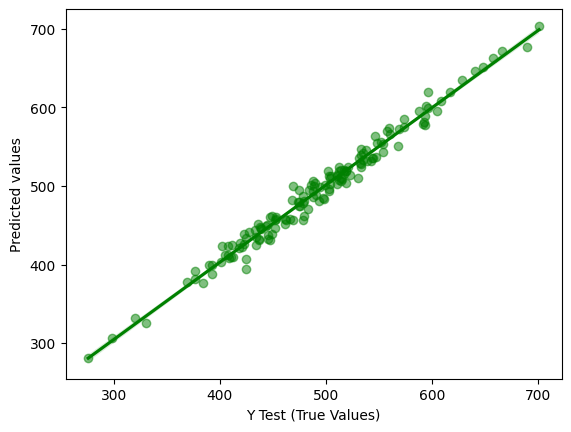

In [37]:
#seaborn.regplot
#Plot data and a linear regression model fit.
sns.regplot(x = y_test,y = y_prediction, color='g',scatter_kws={'alpha':0.5})
plt.xlabel('Y Test (True Values)')
plt.ylabel('Predicted values')
plt.show()